# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `Carvajal, Diego`
- Apellido2, Nombre2: `Ramirez, John`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [1]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1017935628
cedula2 = 1000536111

In [2]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 739
Parámetros — alpha: 2.20, beta: 2.60, gamma: 0.140, ruido: 0.160
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Al interpolar vamos a construir una superficie que pase _exactamente_ por los puntos de z_data. Como estos tienen un ruido (diferencia) respecto a los valores reales (z_true) la superficie resultante no va a pasar por esos datos

b) Si quisieramos aproximar valores por fuera de la superficie, pues por el fenomeno de Runge, los splines no suelen ser buenos para predecir valores fuera de su dominio

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) [ np.ones(n*n)   X_raw.flatten()   Y_raw.flatten() ]

b) Similar al caso 1D, retorna el plano que minimize la distancia (Segun alguna norma) de los puntos reales al plano. Podemos obtener informacion como la orientacion de la superficie, y la distribución (aproximada) de loss datos en el espacio, y como varia esta al movernos en varias direcciones

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:**

a) Como necesitamos medir varianza alrededor de los ejes, necesitamos que los datos esten centrados en el origen para que realmente se muevan alrededor de estos y poder analizar de forma correcta la varianza

b) Al hacer el cambio de base a las componentes principales, el primer eje resultante corresponde a la direccion donde los datos varian mas

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [12]:
from scipy.interpolate import RectBivariateSpline

coords_cont = np.linspace(-3,3,100)
X_cont,Y_cont = np.meshgrid(coords_cont, coords_cont, indexing='ij')

surface =  RectBivariateSpline(x_raw, y_raw, Z_data, kx = 3, ky=3)
surface_data = surface(coords_cont, coords_cont)

### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

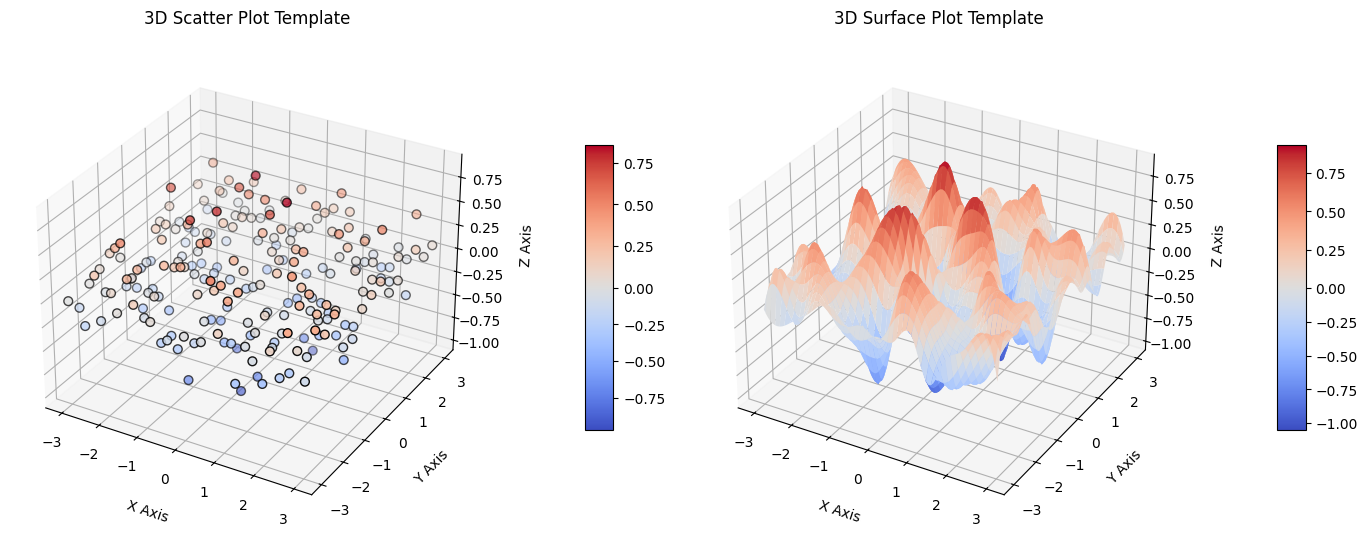

In [19]:

import matplotlib.colors as mcolors  # 1. Import the colors module

# 2. Define the divergent normalization for each dataset.
# This forces 0 to always be white, regardless of data asymmetry.
norm_scatter = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=Z_data.min(), vmax=Z_data.max())
norm_surface = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=surface_data.min(), vmax=surface_data.max())

# Create subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(14, 6))

# Plot 1: 3D Scatter Plot
# Added: cmap='coolwarm' and norm=norm_scatter
sc = ax1.scatter(X_raw, Y_raw, Z_data, c=Z_data, cmap='coolwarm', norm=norm_scatter, s=40, edgecolor='k')
ax1.set_title('3D Scatter Plot Template', pad=20)
ax1.set_xlabel('X Axis', labelpad=10)
ax1.set_ylabel('Y Axis', labelpad=10)
ax1.set_zlabel('Z Axis', labelpad=10)
fig.colorbar(sc, ax=ax1, shrink=0.5, aspect=10, pad=0.15)

# Plot 2: 3D Surface Plot
# Added: norm=norm_surface (cmap is already 'coolwarm')
surf = ax2.plot_surface(X_cont, Y_cont, surface_data, cmap='coolwarm', norm=norm_surface, edgecolor='none')
ax2.set_title('3D Surface Plot Template', pad=20)
ax2.set_xlabel('X Axis', labelpad=10)
ax2.set_ylabel('Y Axis', labelpad=10)
ax2.set_zlabel('Z Axis', labelpad=10)
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, pad=0.15)

plt.tight_layout()

---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [28]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
A = np.column_stack([np.ones(n*n), X_raw.flatten(), Y_raw.flatten()])
c,residuos,_,_ = np.linalg.lstsq(A, Z_data.flatten(), rcond=None) # Added rcond=None to suppress future warnings

text = ['c0', 'c1', 'c2']
for i in range(3):
    print(f"Coeficiente {text[i]}: {c[i]:.4f}")

Coeficiente c0: 0.0112
Coeficiente c1: 0.0037
Coeficiente c2: -0.0006


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

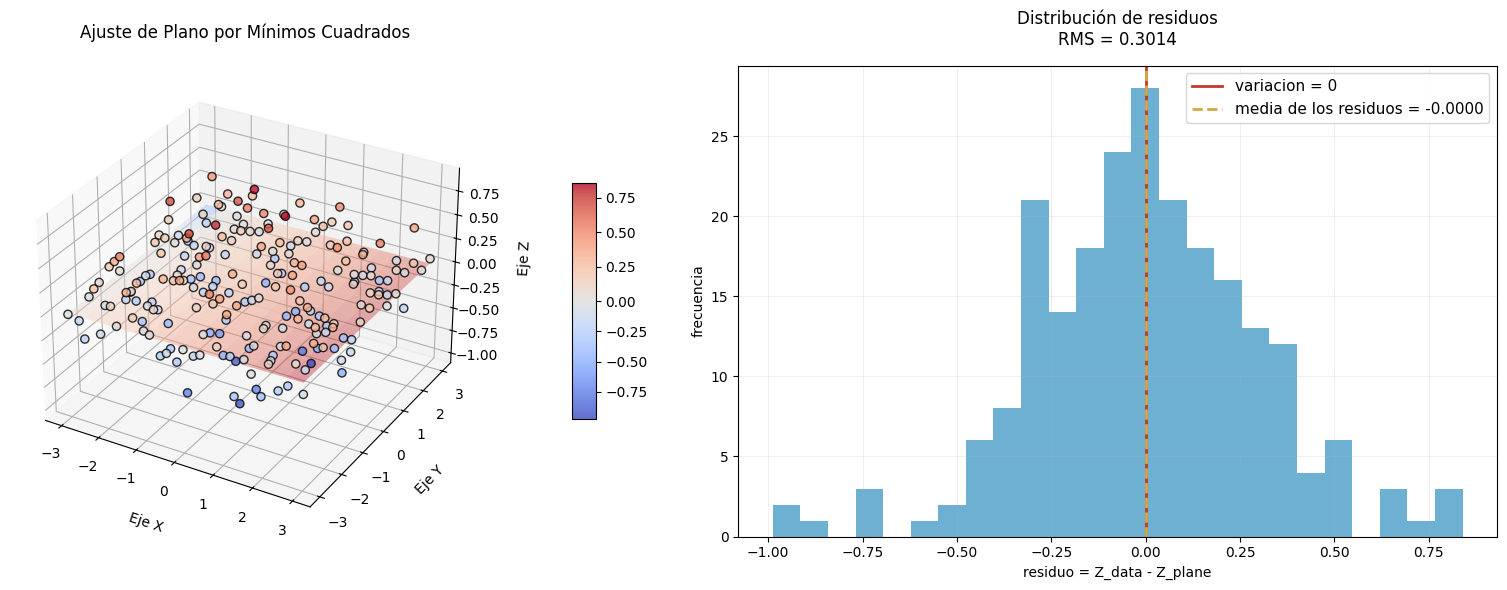

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. Calcular predicciones del plano y residuos individuales
Z_predicted_flat = A @ c
Z_plane = Z_predicted_flat.reshape(n, n)
individual_residuals = Z_data.flatten() - Z_predicted_flat

# Calcular métricas para el histograma
rms = np.sqrt(np.mean(individual_residuals**2))
mean_res = individual_residuals.mean()

# 2. Configurar la normalización bicromática (coolwarm) centrada en cero para el panel 3D
norm_scatter = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=Z_data.min(), vmax=Z_data.max())
norm_surface = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=Z_plane.min(), vmax=Z_plane.max())

# --- Crear la Figura de subplots ---
fig = plt.figure(figsize=(16, 6))

# --- Panel 1 (Izquierdo): Datos 3D + Plano de Mínimos Cuadrados ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Scatter con el mapa 'coolwarm' normalizado en 0
sc = ax1.scatter(X_raw, Y_raw, Z_data, c=Z_data.flatten(), cmap='coolwarm', norm=norm_scatter, s=35, edgecolor='k', alpha=0.8)
# Superficie del plano ajustado
surf = ax1.plot_surface(X_raw, Y_raw, Z_plane, cmap='coolwarm', norm=norm_surface, alpha=0.4, edgecolor='none')

ax1.set_title('Ajuste de Plano por Mínimos Cuadrados', pad=20)
ax1.set_xlabel('Eje X', labelpad=10)
ax1.set_ylabel('Eje Y', labelpad=10)
ax1.set_zlabel('Eje Z', labelpad=10)

# Colorbar para el panel 3D
fig.colorbar(sc, ax=ax1, shrink=0.5, aspect=10, pad=0.12)


# --- Panel 2 (Derecho): Histograma de Distribución de Residuos ---
ax2 = fig.add_subplot(1, 2, 2)

# Histograma con los estilos visuales de tu notebook
ax2.hist(individual_residuals, bins=25, color='#4A9CC7', alpha=0.8, edgecolor='none')

# Línea vertical en residuo = 0
ax2.axvline(0, color='#C0392B', lw=2, label='variacion = 0')

# Línea vertical en el promedio de los residuos
ax2.axvline(mean_res, color='#D4A843', lw=2, ls='--', label=f'media de los residuos = {mean_res:.4f}')

# Etiquetas y títulos adaptados
ax2.set_title(f'Distribución de residuos\nRMS = {rms:.4f}', pad=15)
ax2.set_xlabel('residuo = Z_data - Z_plane')
ax2.set_ylabel('frecuencia')
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [ ]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
